In [1]:
from typing import Dict, TypedDict, List
from langgraph.graph import StateGraph,START,END

In [2]:
class AgentState(TypedDict):
    name: str
    age: str
    final: str

In [3]:
def first_node(state:AgentState) -> AgentState:
    """this is the node whill will take the name"""
    state["final"] = f"Hello Mr.{state["name"]}!"
    return state

def second_node(state:AgentState) -> AgentState:
    """this is the node of the sequenece"""
    state["final"] = state["final"] + f"you are {state['age']} years old!"
    return state



In [5]:
graph = StateGraph(AgentState)

graph.add_node("first_node" , first_node)
graph.add_node("second_node", second_node)

graph.set_entry_point("first_node")
graph.add_edge("first_node" , "second_node")
graph.set_finish_point("second_node")

app = graph.compile()

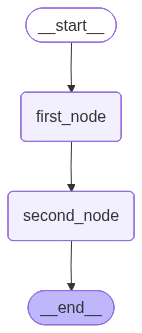

In [6]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [9]:
result = app.invoke({
    "name" : "Junaid",
    "age" : "26"

})

print(result)

{'name': 'Junaid', 'age': '26', 'final': 'Hello Mr.Junaid!you are 26 years old!'}
